<a href="https://colab.research.google.com/github/SalmaAnindhia/PemMes_25_Salma/blob/main/JS05/JS05_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files
files.upload()

Saving insurance.csv to insurance.csv


{'insurance.csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,southwe

In [3]:
data = pd.read_csv('insurance.csv')
data.head()
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Numerik : Age, bmi, children, charges

Kategorikal : Sex, smoker, region

Target : Charges

In [5]:
print("Jumlah data hilang per kolom:")
print(data.isnull().sum())

Jumlah data hilang per kolom:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
print(data_encoded.columns.tolist())

['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [16]:
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

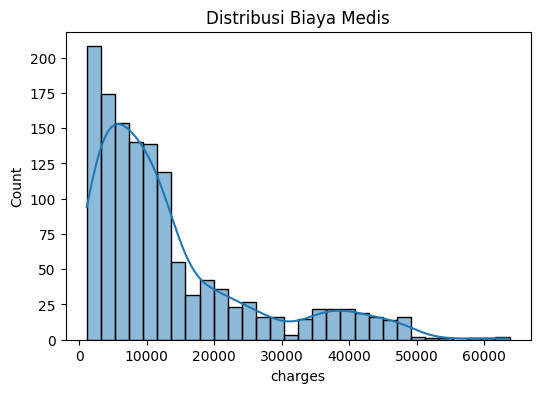

In [12]:
plt.figure(figsize=(6, 4))
sns.histplot(data['charges'], bins=30, kde=True)
plt.title('Distribusi Biaya Medis')
plt.xlabel('charges')
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji  : {X_test.shape[0]}")

Jumlah data latih: 1070
Jumlah data uji  : 268


Multiple linear regression tidak perlu feature scaling, nanti saat tahap svr baru pakai feature scaling, dikarnakan svr sangat sensitif terhadap skala data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [19]:
print("R-squared:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R-squared: 0.7999876970680433
MAE: 3933.272649405236
MSE: 31827950.229523838


In [22]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train) #menghitung mean/std dari train, lalu scale train
y_train_scaled = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()  #reshape karena scaler butuh 2D, ravel karena SVR butuh 1D
X_test_scaled = sc_X.transform(X_test)

svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train_scaled)

y_pred_svr = svr.predict(X_test_scaled) # memprediksi data uji
y_pred_svr = sc_y.inverse_transform(y_pred_svr.reshape(-1, 1)).ravel() # membalikin ke skala asli agar bisa dibandingkan dengan y_test

In [23]:
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],  # jenis kernel yang akan dicoba
    'C': [0.1, 1, 10, 100],               # C besar = model lebih fleksibel (risk overfitting), C kecil = lebih sederhana
    'epsilon': [0.01, 0.1, 0.5],          # toleransi error, semakin besar semakin longgar
    'gamma': ['scale', 'auto']            # pengaruh tiap data point, khusus kernel rbf/poly
}

grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', n_jobs=-1)
# mencoba semua kombinasi param_grid, yg dinilai pakai r2, 5-fold cross validation, n_jobs=-1 = agar semua CPU biar cepat

grid.fit(X_train_scaled, y_train_scaled)  # menjalankan tuning memakai data latih

print("Parameter terbaik:", grid.best_params_)  # kombinasi parameter dengan skor tertinggi
print("Skor terbaik:", grid.best_score_)        # skor r2 rata-rata dari cross validation

# Pakai model terbaik untuk prediksi
svr_best = grid.best_estimator_      # ambil model SVR dengan parameter terbaik
y_pred_best = svr_best.predict(X_test_scaled)  # prediksi data uji
y_pred_best = sc_y.inverse_transform(y_pred_best.reshape(-1, 1)).ravel()  # membalikin skala asli

Parameter terbaik: {'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Skor terbaik: 0.8216360461794189


In [24]:
print("=== SVR (default) ===")
print("R2 :", r2_score(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))

print("=== SVR (tuned) ===")
print("R2 :", r2_score(y_test, y_pred_best))
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))

=== SVR (default) ===
R2 : 0.8889571267537948
MAE: 2422.8701355002963
MSE: 17670248.2358092
=== SVR (tuned) ===
R2 : 0.8889571267537948
MAE: 2422.8701355002963
MSE: 17670248.2358092


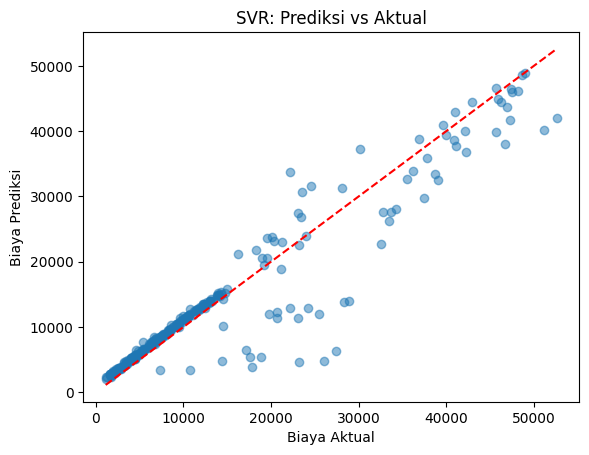

In [25]:
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Biaya Aktual')
plt.ylabel('Biaya Prediksi')
plt.title('SVR: Prediksi vs Aktual')
plt.show()